In [ ]:
# Load and check what is inside
import os
import torch

from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too
from maren_data.helpers import choose_data_params

sampler_type = "grid"
location = "vast" # vast or scratch


# Save the ones that ran correctly
successful_models = {}
data = "shd"
seeds = [1, 2, 3, 4, 5]
percent_data = [0.25, 0.5, 1.0]
if data == "shd":
    num_hidden = [256, 128, 64]
elif data == "randman":
    num_hidden = [20, 10, 5]
    # Adjust these as needed
    num_classes = 5
    num_dim = 1
    alpha = 3

missing = {}
# Add model classes to dictionary with test accuracy values (we'll take averages at the end)
for model_name in MODEL_CLASSES.keys():
    print(f"Evaluating model: {model_name}")
    successful_models[model_name] = {}
    missing[model_name] = {}    
    if "Hybrid" in model_name and "Flexible" not in model_name:
        percents = [0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95]
    else:
        percents = [None]
    if "NSN" in model_name:
        nsn_reset = [True, False]
    else:
        nsn_reset = [True]
    for percent in percents:
        successful_models[model_name][percent] = {}
        missing[model_name][percent] = {}
        for pct_data in percent_data:
            successful_models[model_name][percent][pct_data] = {}
            missing[model_name][percent][pct_data] = {}
            for n_hidden in num_hidden:
                successful_models[model_name][percent][pct_data][n_hidden] = {}
                missing[model_name][percent][pct_data][n_hidden] = {}
                # Check per-seed whether the trained checkpoint exists.
                for n in nsn_reset:
                    successful_models[model_name][percent][pct_data][n_hidden][f"reset_nsn_{n}"] = []
                    missing[model_name][percent][pct_data][n_hidden][f"reset_nsn_{n}"].append([]) if False else missing[model_name][percent][pct_data][n_hidden].update({f"reset_nsn_{n}": []})
                    for seed in seeds:
                        if data == "shd":
                            base_dir = f"/{location}/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        elif data == "randman":
                            base_dir = f"/{location}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/{alpha}/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        else:
                            base_dir = None

                        if n == True:
                           base_dir = os.path.join(base_dir, 'best_model_of_study.ckpt')
                        else:
                           base_dir = os.path.join(base_dir, 'reset_nsn_False', 'best_model_of_study.ckpt')
                        if os.path.exists(base_dir):
                            successful_models[model_name][percent][pct_data][n_hidden][f"reset_nsn_{n}"].append(seed)
                        else:
                            missing[model_name][percent][pct_data][n_hidden][f"reset_nsn_{n}"].append(seed)
                            print(f"Missing model file for seed {seed} at {base_dir}")


Evaluating model: SNN
Missing model file for seed 1 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_1/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 2 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_2/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 3 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_3/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 4 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_4/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 5 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True

Evaluating model: NSN_with_LIF_output
Missing model file for seed 1 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_1/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 2 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_2/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 3 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_3/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 4 at /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/NSN_with_LIF_output/recurrent_True/seed_4/tpe_sampler/256_hidden/0.25_pct_data/None_percent_snn/best_model_of_study.ckpt
Missing model file for seed 5 at /vast/nar8991

In [79]:
"/vast/nar8991/snn/training_results/randman/1_d/5_classes/3/cross_entropy/SNN_2_Layer/recurrent_True/seed_2/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt"

'/vast/nar8991/snn/training_results/randman/1_d/5_classes/3/cross_entropy/SNN_2_Layer/recurrent_True/seed_2/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt'

In [80]:
missing['SNN_2_Layer']

{None: {0.25: {256: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   128: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   64: {'reset_nsn_True': [1, 2, 3, 4, 5]}},
  0.5: {256: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   128: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   64: {'reset_nsn_True': [1, 2, 3, 4, 5]}},
  1.0: {256: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   128: {'reset_nsn_True': [1, 2, 3, 4, 5]},
   64: {'reset_nsn_True': [1, 2, 3, 4, 5]}}}}

In [81]:

# Look at the ones that are missing
successful_models['SNN_2_Layer']

{None: {0.25: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}},
  0.5: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}},
  1.0: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}}}}

In [82]:
from test_visualizations.utils import get_randman_test_data, get_shd_test_data
if data == "shd":
    test_loader = get_shd_test_data()
elif data == "randman":
    test_loader = get_randman_test_data(num_dim=num_dim, num_classes=num_classes, alpha=alpha)
else:
    raise ValueError("Data must be 'shd' or 'randman'")

choose data params for shd
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([11])]
encoding dim: 700, sensor size: (700, 1, 1)
Encoding dimension 700 matches the product of sensor size 700. No downsampling needed.
Cropping time to 1 seconds (1000000.0 microseconds).
data already downloaded: True
[tensor([[[0, 0, 0,  ..., 0, 1, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], dtype=torch.int16), tensor([10])]
Train class distributio

In [83]:
from tqdm import tqdm

def compute_accuracy(model, test_loader=test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.test_accuracy.reset()
    model.to(device)
    model.zero_grad()
    # criterion = nn.CrossEntropyLoss()
    for inputs, targets in tqdm(test_loader, desc="Testing"):
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        model.test_accuracy.update(logit_output, targets)
    test_acc = model.test_accuracy.compute().item()
    return test_acc

In [84]:
successful_models['Hybrid_NSN_SNN_V1_same_layer'][0.5][1.0]

{256: {'reset_nsn_True': [], 'reset_nsn_False': []},
 128: {'reset_nsn_True': [], 'reset_nsn_False': []},
 64: {'reset_nsn_True': [], 'reset_nsn_False': []}}

In [85]:
data

'shd'

In [86]:
final_test_accuracies = {}

for model_name, percent_dict in successful_models.items():
    final_test_accuracies[model_name] = {}
    for percent, pct_data_dict in percent_dict.items():
        final_test_accuracies[model_name][percent] = {}
        for pct_data, n_hidden_dict in pct_data_dict.items():
            final_test_accuracies[model_name][percent][pct_data] = {}
            for n_hidden, reset_nsn_dict in n_hidden_dict.items():
                final_test_accuracies[model_name][percent][pct_data][n_hidden] = {}
                for reset_nsn_key, seed_list in reset_nsn_dict.items():
                    test_accuracies = []
                    for seed in seed_list:
                        print(base_dir)
                        if data == "shd":
                            base_dir = f"/{location}/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        elif data == "randman":
                            base_dir = f"/{location}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/{alpha}/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/20_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        if reset_nsn_key == "reset_nsn_True":
                            path = os.path.join(base_dir, "best_model_of_study.ckpt")
                        else:
                            path = os.path.join(base_dir, 'reset_nsn_False', 'best_model_of_study.ckpt')
                        model_class = MODEL_CLASSES[model_name]
                        print(f"Loading model from {path}")
                        model = model_class.load_from_checkpoint(path, strict=False)
                        test_acc = compute_accuracy(model, test_loader=test_loader)
                        test_accuracies.append(test_acc)
                    final_test_accuracies[model_name][percent][pct_data][n_hidden][reset_nsn_key] = test_accuracies


/vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN_2_Layer/recurrent_True/seed_5/tpe_sampler/64_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt
Loading model from /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_1/tpe_sampler/256_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing:   0%|          | 0/9 [00:00<?, ?it/s]

Testing: 100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


/vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_1/tpe_sampler/256_hidden/1.0_pct_data/None_percent_snn/
Loading model from /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/SNN/recurrent_True/seed_2/tpe_sampler/256_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 9/9 [00:05<00:00,  1.56it/s]


...

Testing: 100%|██████████| 9/9 [00:06<00:00,  1.43it/s]


/vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_3/tpe_sampler/64_hidden/1.0_pct_data/0.95_percent_snn/
Loading model from /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_4/tpe_sampler/64_hidden/1.0_pct_data/0.95_percent_snn/reset_nsn_False/best_model_of_study.ckpt


Testing: 100%|██████████| 9/9 [00:06<00:00,  1.44it/s]


/vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_4/tpe_sampler/64_hidden/1.0_pct_data/0.95_percent_snn/
Loading model from /vast/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/Hybrid_NSN_SNN_V1_same_layer/recurrent_True/seed_5/tpe_sampler/64_hidden/1.0_pct_data/0.95_percent_snn/reset_nsn_False/best_model_of_study.ckpt


Testing: 100%|██████████| 9/9 [00:06<00:00,  1.43it/s]


In [87]:
# final_test_accuracies = {}
# for model_name in successful_models.keys():
#     final_test_accuracies[model_name] = {}
#     for percent in successful_models[model_name].keys():
#         final_test_accuracies[model_name][percent] = []
#         for seed in successful_models[model_name][percent]:
#             path = f"/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/256_hidden/1.0_pct_data/{percent}_percent_snn/best_model_of_study.ckpt"
#             model_class = MODEL_CLASSES[model_name]
#             print(f"Loading model from {path}")
#             model = model_class.load_from_checkpoint(path, strict=False)
#             test_acc = compute_accuracy(model, test_loader=test_loader)
#             final_test_accuracies[model_name][percent].append(test_acc)
#             print(f"Model: {model_name}, Percent: {percent}, Seed: {seed}, Test Acc: {test_acc}")

In [88]:
final_test_accuracies.keys()

dict_keys(['SNN', 'ANN_with_LIF_output', 'NSN_with_LIF_output', 'Hybrid_RNN_SNN_rec', 'Hybrid_NSN_SNN_rec', 'Hybrid_RNN_SNN_V1_same_layer', 'Hybrid_NSN_SNN_V1_same_layer', 'Hybrid_NSN_SNN_V1_Flexible_Spiking', 'SNN_2_Layer'])

In [89]:
final_test_accuracies['SNN_2_Layer']

{None: {0.25: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}},
  0.5: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}},
  1.0: {256: {'reset_nsn_True': []},
   128: {'reset_nsn_True': []},
   64: {'reset_nsn_True': []}}}}

In [90]:
# Take the dictionary and convert it to a dataframe
import pandas as pd

remapping = {
    "SNN": "SNN",
    "ANN_with_LIF_output": "RNN",
    "NSN_with_LIF_output": "Nonspiking",
    "Hybrid_RNN_SNN_rec": "Network-to-Network RNN",
    "Hybrid_NSN_SNN_rec": "Network-to-Network Nonspiking",
    "Hybrid_RNN_SNN_V1_same_layer": "Same Layer RNN",
    "Hybrid_NSN_SNN_V1_same_layer": "Same Layer Nonspiking",
}


def convert_dict_to_df(final_test_accuracies):
    df_rows = []
    for original_model_name, percent_dict in final_test_accuracies.items():
        # Determine if this is an NSN model from the original key
        is_nsn_model = ('NSN' in original_model_name)
        # Apply remapping for display
        model_name = remapping.get(original_model_name, original_model_name)

        for percent_snn, percent_data in percent_dict.items():
            for percent_data, hidden_data in percent_data.items():
                for hidden_size, nsn_dict in hidden_data.items():
                    for reset_nsn_key, accuracies in nsn_dict.items():
                        # # normalize reset_nsn_key to boolean/None: expected values like 'reset_nsn_True' or 'reset_nsn_False'
                        # nsn_reset_val = None
                        if isinstance(reset_nsn_key, str) and reset_nsn_key.startswith('reset_nsn_'):
                            key_tail = reset_nsn_key.split('reset_nsn_')[-1]
                            if key_tail == 'True':
                                nsn_reset_val = True
                            elif key_tail == 'False':
                                nsn_reset_val = False
                            # else:
                            #     nsn_reset_val = None

                        # If this is not an NSN model, ignore any reset flag and set to None
                        if not is_nsn_model:
                            nsn_reset_val = None

                        if len(accuracies) > 0:
                            avg_acc = sum(accuracies) / len(accuracies)
                            std_acc = (sum((x - avg_acc) ** 2 for x in accuracies) / len(accuracies)) ** 0.5
                            df_rows.append({
                                "Model": model_name,
                                "Percent_SNN": percent_snn,
                                "Percent_Data": percent_data,
                                "Hidden_Size": hidden_size,
                                "mean_value": avg_acc,
                                "std_value": std_acc,
                                "nsn_reset": nsn_reset_val,
                                "count": len(accuracies)
                            })
                        else:
                            df_rows.append({
                                "Model": model_name,
                                "Percent_SNN": percent_snn,
                                "Percent_Data": percent_data,
                                "Hidden_Size": hidden_size,
                                "mean_value": None,
                                "std_value": None,
                                "nsn_reset": nsn_reset_val,
                                "count": 0
                            })
    results_df = pd.DataFrame(df_rows)
    # Ensure nsn_reset column exists and string-safe
    if 'nsn_reset' not in results_df.columns:
        results_df['nsn_reset'] = None

    # Create run_group to include nsn_reset only for NSN models so plotting treats reset variants separately
    def build_run_group(row):
        base = f"{row['Model']}_pct_{row['Percent_SNN']}"
        if (row.get('nsn_reset') is not None) and (str(row['Model']).lower().find('nsn') != -1 or True):
            # We stored nsn_reset only for NSN models above; this conditional guards inclusion.
            # The check `str(row['Model']).lower().find('nsn') != -1 or True` intentionally allows
            # inclusion if nsn_reset is not None. However, since we forced nsn_reset=None for
            # non-NSN models earlier, this will only add the reset suffix for NSN models.
            return base + f"_reset_{row['nsn_reset']}"
        else:
            return base

    results_df['run_group'] = results_df.apply(build_run_group, axis=1)
    results_df['metric'] = 'Test Accuracy'
    # Drop rows where mean_value is None
    # results_df.dropna(subset=['mean_value'], inplace=True)
    return results_df

results_df = convert_dict_to_df(final_test_accuracies)


In [91]:
results_df[results_df['Model'] == 'Nonspiking']

,Model,Percent_SNN,Percent_Data,Hidden_Size,mean_value,std_value,nsn_reset,count,run_group,metric
18,Nonspiking,NaN,0.25,256,NaN,NaN,True,0,Nonspiking_pct_nan_reset_True,Test Accuracy
19,Nonspiking,NaN,0.25,256,0.614223,0.047523,False,5,Nonspiking_pct_nan_reset_False,Test Accuracy
20,Nonspiking,NaN,0.25,128,NaN,NaN,True,0,Nonspiking_pct_nan_reset_True,Test Accuracy
21,Nonspiking,NaN,0.25,128,NaN,NaN,False,0,Nonspiking_pct_nan_reset_False,Test Accuracy
22,Nonspiking,NaN,0.25,64,NaN,NaN,True,0,Nonspiking_pct_nan_reset_True,Test Accuracy
23,Nonspiking,NaN,0.25,64,NaN,NaN,False,0,Nonspiking_pct_nan_reset_False,Test Accuracy
24,Nonspiking,NaN,0.50,256,NaN,NaN,True,0,Nonspiking_pct_nan_reset_True,Test Accuracy
25,Nonspiking,NaN,0.50,256,0.615018,0.048800,False,5,Nonspiking_pct_nan_reset_False,Test Accuracy
26,Nonspiking,NaN,0.50,128,NaN,NaN,True,0,Nonspiking_pct_nan_reset_True,Test Accuracy
27,Nonspiking,NaN,0.50,128,NaN,NaN,False,0,Nonspiking_pct_nan_reset_False,Test Accuracy


In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import colorsys


def _plot_bars(ax, x_positions, values, std_values, bar_width, label, colors=None):
    if colors is None:
        bars = ax.bar(x_positions, values, yerr=std_values, width=bar_width, label=label,
                      capsize=4, alpha=0.7, error_kw={'elinewidth':1, 'ecolor':'black'})
    else:
        bars = ax.bar(x_positions, values, yerr=std_values, width=bar_width, label=label,
                      color=colors, capsize=4, alpha=0.9, error_kw={'elinewidth':1, 'ecolor':'black'})
    return bars


def _annotate_bars(ax, bars, values, std_values, extra_labels=None):
    for j, bar in enumerate(bars):
        value = values[j]
        if value is None or (isinstance(value, float) and np.isnan(value)):
            continue
        if value > 0:
            sd = std_values[j] if std_values[j] is not None else 0
            text_y_position = value + (sd if sd > 0 else 0) + 0.01
            label_text = f'{value:.3f}'
            if extra_labels and extra_labels[j]:
                label_text += extra_labels[j]
            ax.text(bar.get_x() + bar.get_width()/2., text_y_position,
                    label_text, ha='center', va='bottom', fontsize=8, rotation=0)



def get_model_color_map(df, base_palette='tab10'):
    """
    Return a mapping: model_name -> {(percent_snn, nsn_reset): rgba}
    where nsn_reset is True/False/None and percent_snn may be None.
    """
    models = list(df['Model'].unique())
    cmap_base = plt.get_cmap(base_palette)
    n_models = max(1, len(models))
    base_colors = [cmap_base(i / max(1, n_models - 1)) for i in range(n_models)]
    color_map = {}
    for i, m in enumerate(models):
        base_rgb = mcolors.to_rgb(base_colors[i])
        # collect unique (percent_snn, nsn_reset) pairs for this model
        rows = df.loc[df['Model'] == m, ['Percent_SNN', 'nsn_reset']].drop_duplicates()
        pairs = []
        for _, r in rows.iterrows():
            p = r['Percent_SNN'] if not pd.isna(r['Percent_SNN']) else None
            nr = r['nsn_reset'] if not pd.isna(r['nsn_reset']) else None
            pairs.append((p, nr))
        # ensure at least one entry
        if len(pairs) == 0:
            pairs = [(None, None)]
        shades = {}
        mcount = max(1, len(pairs))
        for j, pair in enumerate(pairs):
            # compute lightness varying across j
            light = 0.35 + 0.55 * (j / max(1, mcount - 1))
            h, l, s = colorsys.rgb_to_hls(*base_rgb)
            rgb_shade = colorsys.hls_to_rgb(h, light, s)
            rgba = (*rgb_shade, 1.0)
            shades[pair] = rgba
        color_map[m] = shades
    return color_map


def plot_metric_distribution(df_means, metrics, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    has_counts = 'count' in df_means.columns
    run_groups = sorted(df_means['run_group'].unique())
    run_group_labels = []
    color_map = get_model_color_map(df_means)
    for group in run_groups:
        group_df = df_means[df_means['run_group'] == group]
        lr_for_label = None
        # extract nsn_reset for label if present
        nsn_reset_for_label = None
        if 'nsn_reset' in group_df.columns and not group_df['nsn_reset'].isna().all():
            nsn_reset_for_label = group_df['nsn_reset'].iloc[0]
        if 'val_accuracy' in group_df['metric'].values and 'learning_rate' in group_df.columns:
            lr_row = group_df[group_df['metric'] == 'val_accuracy'].iloc[0]
            lr_for_label = lr_row['learning_rate']
        elif not group_df.empty and 'learning_rate' in group_df.columns:
            lr_for_label = group_df['learning_rate'].iloc[0]
        # include reset info in label if present
        if lr_for_label is not None:
            if nsn_reset_for_label is not None:
                run_group_labels.append(f"{group}\n(reset: {nsn_reset_for_label}, lr: {lr_for_label:.1e})")
            else:
                run_group_labels.append(f"{group}\n(lr: {lr_for_label:.1e})")
        else:
            if nsn_reset_for_label is not None:
                run_group_labels.append(f"{group}\n(reset: {nsn_reset_for_label})")
            else:
                run_group_labels.append(group)
    bar_width = 0.8 / len(metrics)
    x_positions = np.arange(len(run_groups))
    for i, metric in enumerate(metrics):
        df_metric = df_means[df_means['metric'] == metric]
        values, std_values, counts, colors = [], [], [], []
        for group in run_groups:
            group_data = df_metric[df_metric['run_group'] == group]
            if not group_data.empty:
                v = group_data['mean_value'].iloc[0]
                s = group_data['std_value'].iloc[0]
                c = group_data['count'].iloc[0] if has_counts else None
                model_name = group_data['Model'].iloc[0] if 'Model' in group_data.columns else group.split('_pct_')[0]
                percent = group_data['Percent_SNN'].iloc[0] if 'Percent_SNN' in group_data.columns else None
                nsn_reset = group_data['nsn_reset'].iloc[0] if 'nsn_reset' in group_data.columns else None
                if pd.isna(percent):
                    percent = None
                if pd.isna(nsn_reset):
                    nsn_reset = None
                color = color_map.get(model_name, {}).get((percent, nsn_reset), None)
                values.append(v if v is not None else 0)
                std_values.append(s if s is not None else 0)
                counts.append(c)
                colors.append(color)
            else:
                values.append(0)
                std_values.append(0)
                counts.append(None)
                colors.append(None)
        x_offset = x_positions + (i - len(metrics)/2 + 0.5) * bar_width
        bars = _plot_bars(ax, x_offset, values, std_values, bar_width, metric, colors=colors)
        extra_labels = [f'\n(n={int(c)})' if has_counts and c is not None else '' for c in counts]
        _annotate_bars(ax, bars, values, std_values, extra_labels)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(run_group_labels, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.set_xlabel('Run Group (with Learning Rate)')
    # Place legend outside plot area
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax


def plot_metric_distribution_param_based(param_name, param_range, df_means, metric, title=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    run_groups = sorted(df_means['run_group'].unique())
    df_metric = df_means[df_means['metric'] == metric]
    bar_width = 0.8 / len(run_groups)
    x_positions = np.arange(len(param_range))
    color_map = get_model_color_map(df_means)
    for i, group in enumerate(run_groups):
        df_group = df_metric[df_metric['run_group'] == group]
        values, std_values, lrs, counts, colors = [], [], [], [], []
        if not df_group.empty and 'Model' in df_group.columns:
            model_name = df_group['Model'].iloc[0]
            percent_for_group = df_group['Percent_SNN'].iloc[0]
            nsn_reset_for_group = df_group['nsn_reset'].iloc[0] if 'nsn_reset' in df_group.columns else None
            if pd.isna(percent_for_group):
                percent_for_group = None
            if pd.isna(nsn_reset_for_group):
                nsn_reset_for_group = None
        else:
            model_name = group.split('_pct_')[0]
            percent_for_group = None
            nsn_reset_for_group = None
        for p_val in param_range:
            param_data = df_group[df_group[param_name] == p_val]
            if not param_data.empty:
                values.append(param_data['mean_value'].iloc[0])
                std_values.append(param_data['std_value'].iloc[0])
                lrs.append(param_data['learning_rate'].iloc[0] if 'learning_rate' in param_data.columns else None)
                counts.append(param_data['count'].iloc[0] if 'count' in param_data.columns else None)
            else:
                values.append(0)
                std_values.append(0)
                lrs.append(None)
                counts.append(None)
            colors.append(color_map.get(model_name, {}).get((percent_for_group, nsn_reset_for_group), None))
        x_offset = x_positions + (i - len(run_groups)/2 + 0.5) * bar_width
        bars = _plot_bars(ax, x_offset, values, std_values, bar_width, group, colors=colors)
        extra_labels = [
            (f'\n(lr: {lrs[j]:.1e})' if lrs[j] is not None else '') +
            (f'\n(n={int(counts[j])})' if counts[j] is not None else '')
            for j in range(len(values))
        ]
        _annotate_bars(ax, bars, values, std_values, extra_labels)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right')
    ax.set_title(title if title else f'{metric} Distribution by {param_name}')
    ax.set_ylabel(metric)
    ax.set_xlabel(param_name)
    ax.legend(title='Run Group', loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax


In [93]:

filtered_df = results_df[(results_df['Percent_Data']==1.0) & (results_df['Hidden_Size']==num_hidden[0]) & ((results_df['Percent_SNN'].isna()) | (results_df['Percent_SNN'] == 0.5))]
filtered_df

,Model,Percent_SNN,Percent_Data,Hidden_Size,mean_value,std_value,nsn_reset,count,run_group,metric
6,SNN,NaN,1.0,256,0.658304,0.050708,None,5,SNN_pct_nan,Test Accuracy
15,RNN,NaN,1.0,256,0.480654,0.045971,None,5,RNN_pct_nan,Test Accuracy
30,Nonspiking,NaN,1.0,256,0.359452,0.071880,True,5,Nonspiking_pct_nan_reset_True,Test Accuracy
31,Nonspiking,NaN,1.0,256,0.625088,0.083646,False,5,Nonspiking_pct_nan_reset_False,Test Accuracy
51,Network-to-Network RNN,0.5,1.0,256,NaN,NaN,None,0,Network-to-Network RNN_pct_0.5,Test Accuracy
129,Network-to-Network Nonspiking,0.5,1.0,256,NaN,NaN,True,0,Network-to-Network Nonspiking_pct_0.5_reset_True,Test Accuracy
130,Network-to-Network Nonspiking,0.5,1.0,256,NaN,NaN,False,0,Network-to-Network Nonspiking_pct_0.5_reset_False,Test Accuracy
240,Same Layer RNN,0.5,1.0,256,NaN,NaN,None,0,Same Layer RNN_pct_0.5,Test Accuracy
318,Same Layer Nonspiking,0.5,1.0,256,NaN,NaN,True,0,Same Layer Nonspiking_pct_0.5_reset_True,Test Accuracy
319,Same Layer Nonspiking,0.5,1.0,256,NaN,NaN,False,0,Same Layer Nonspiking_pct_0.5_reset_False,Test Accuracy


<Axes: title={'center': 'Test Accuracy by Model and Percent SNN'}, xlabel='Run Group (with Learning Rate)', ylabel='Value'>

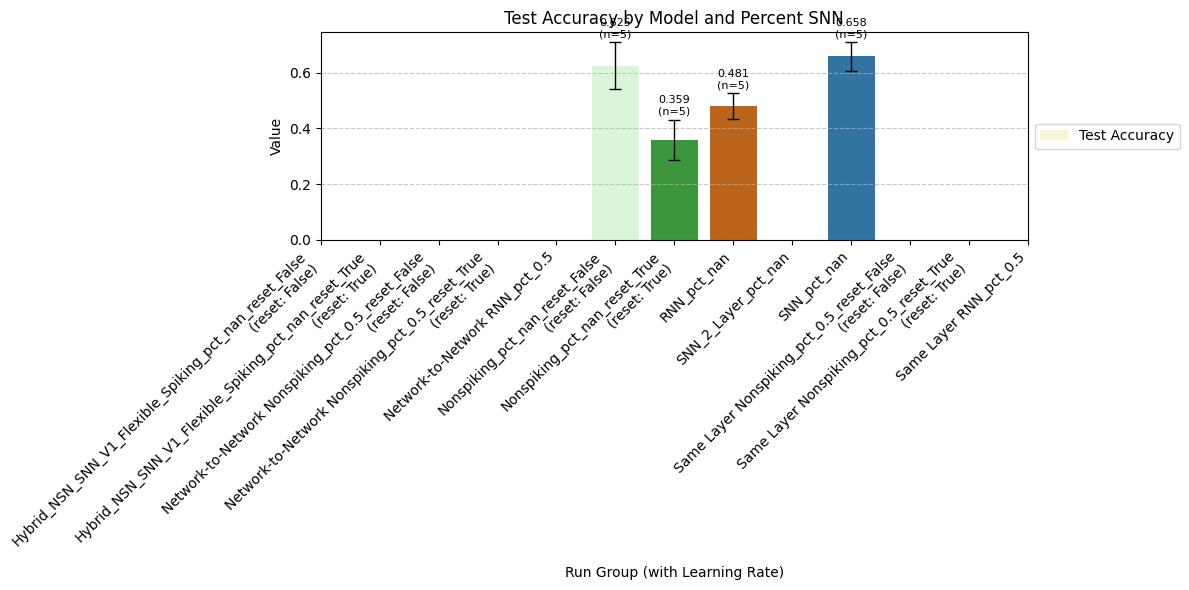

In [94]:
# Need to rerun so we do more trials, they're still too low for SNN
plot_metric_distribution(filtered_df, metrics=["Test Accuracy"], title="Test Accuracy by Model and Percent SNN")

<Axes: title={'center': 'Test Accuracy by Hidden Size and Model'}, xlabel='Hidden_Size', ylabel='Test Accuracy'>

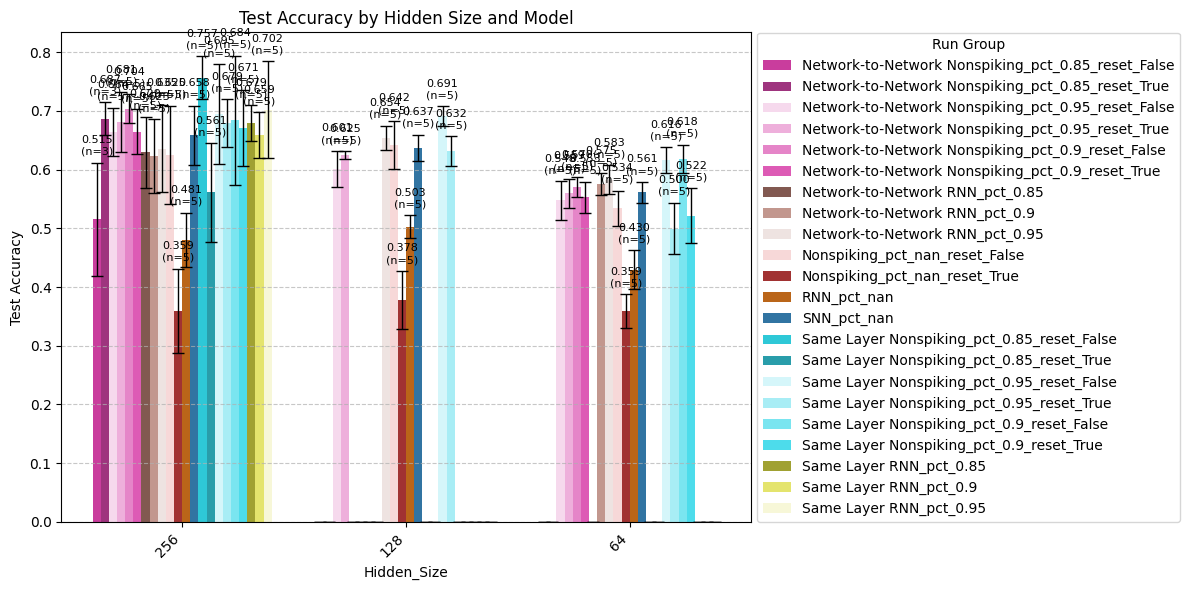

In [95]:
filtered_df = results_df[(results_df['mean_value'].notna())&(results_df['Percent_Data']==1.0)]
plot_metric_distribution_param_based("Hidden_Size", num_hidden, filtered_df, metric="Test Accuracy", title="Test Accuracy by Hidden Size and Model")

<Axes: title={'center': 'Test Accuracy by Percent Data and Model'}, xlabel='Percent_Data', ylabel='Test Accuracy'>

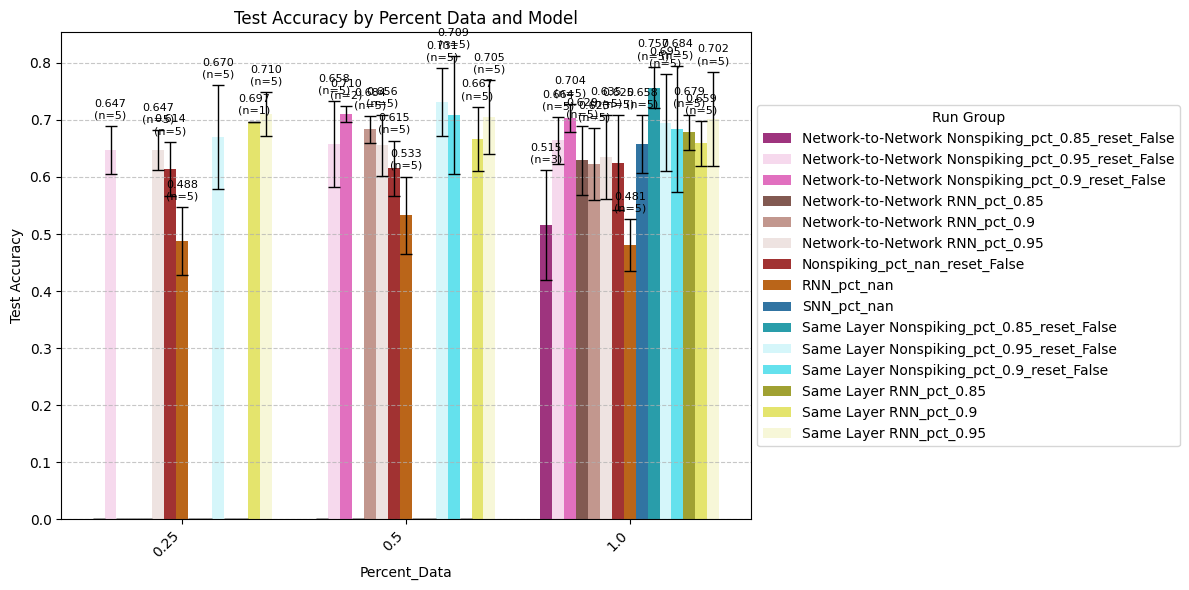

In [96]:
# All
filtered_df = results_df[(results_df['mean_value'].notna())&(results_df['Hidden_Size']==256) & (results_df['nsn_reset']!=True)]
plot_metric_distribution_param_based("Percent_Data", [0.25, 0.5, 1.0], filtered_df, metric="Test Accuracy", title="Test Accuracy by Percent Data and Model")

<Axes: title={'center': 'Test Accuracy by Percent Data and Model'}, xlabel='Percent_Data', ylabel='Test Accuracy'>

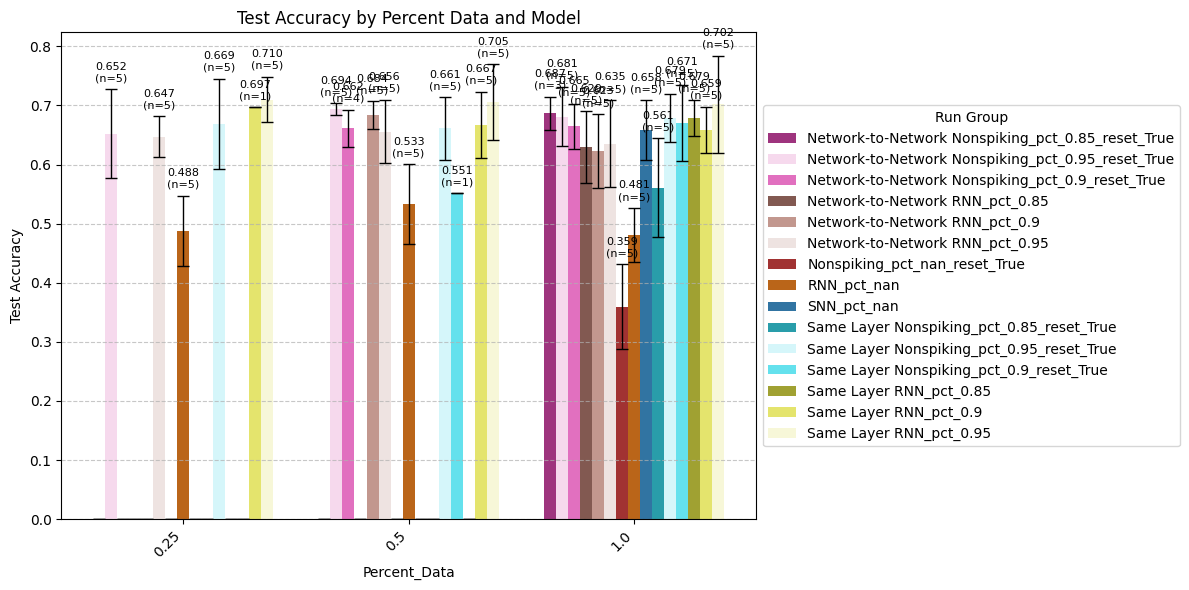

In [97]:
# All
filtered_df = results_df[(results_df['mean_value'].notna())&(results_df['Hidden_Size']==256) & (results_df['nsn_reset']!=False)]
plot_metric_distribution_param_based("Percent_Data", [0.25, 0.5, 1.0], filtered_df, metric="Test Accuracy", title="Test Accuracy by Percent Data and Model")

<Axes: title={'center': 'Test Accuracy by Percent Data and Model'}, xlabel='Percent_Data', ylabel='Test Accuracy'>

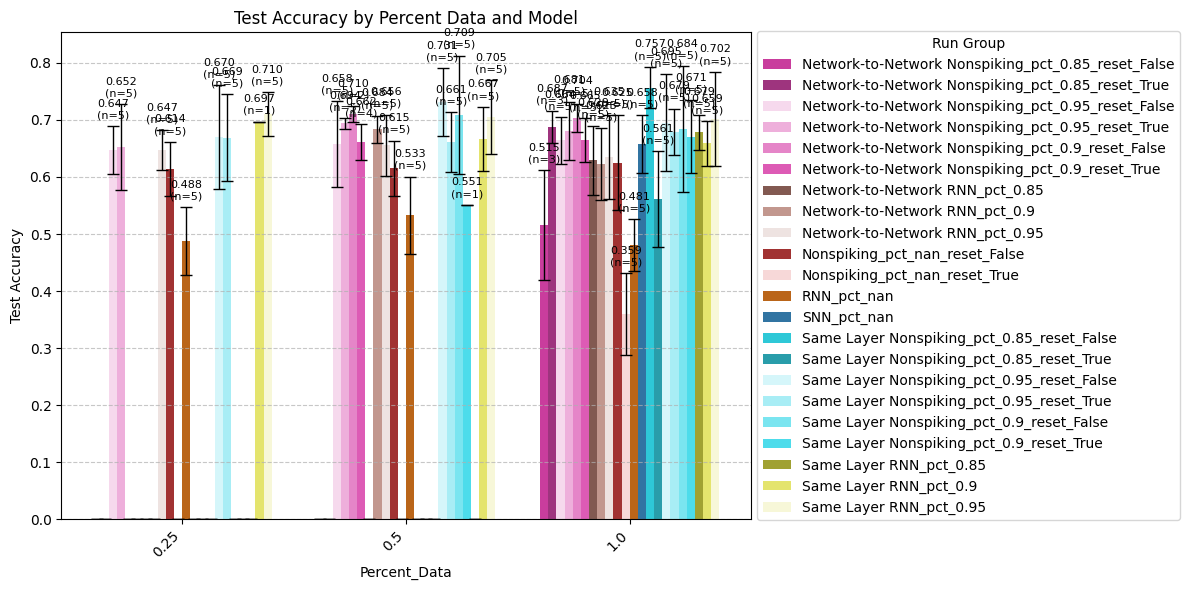

In [98]:
# All
filtered_df = results_df[(results_df['mean_value'].notna())&(results_df['Hidden_Size']==256)]
plot_metric_distribution_param_based("Percent_Data", [0.25, 0.5, 1.0], filtered_df, metric="Test Accuracy", title="Test Accuracy by Percent Data and Model")

In [99]:
# TO DO: save as function and then run with SHD (also add function to generate missing data)
def update_missing_experiments_csv(missing, existing_csv_file="missing_experiments_shd.csv", 
                                 data="randman", dim_manifold=1, num_classes=2, alpha=3, 
                                 sampler_type=sampler_type, gamma_init_type="rand", 
                                 gamma_fixed=False, reset_nsn=True, no_non_recurrent=True,
                                 output_file=None):
    """
    Generate a CSV file with missing experiment configurations based on the missing dictionary.
    """
    missing_rows = []

    if output_file is None:
        output_file = existing_csv_file  # Update in place
    
    # Read existing CSV if it exists
    try:
        df_existing = pd.read_csv(existing_csv_file)
        print(f"Loaded existing CSV with {len(df_existing)} experiments")
    except FileNotFoundError:
        print(f"No existing CSV found at {existing_csv_file}, creating new one")
        df_existing = pd.DataFrame()

    # Filter the existing DataFrame to only include relevant rows
    if not df_existing.empty:
        df_existing_filtered = df_existing[
            (df_existing['data'] == data) &
            (df_existing['dim_manifold'] == dim_manifold) &
            (df_existing['num_classes'] == num_classes) &
            (df_existing['alpha'] == alpha) &
            (df_existing['sampler_type'] == sampler_type) &
            (df_existing['gamma_init_type'] == gamma_init_type) &
            (df_existing['gamma_fixed'] == gamma_fixed) &
            (df_existing['reset_nsn'] == reset_nsn) &
            (df_existing['no_non_recurrent'] == no_non_recurrent)
        ]
        print(f"Filtered existing CSV to {len(df_existing_filtered)} relevant experiments")

    # See if any of the missing experiments are no longer missing (i.e., in CSV but no longer there)
    
    for model_name, percent_dict in missing.items():
        for percent, missing_seeds in percent_dict.items():
            if missing_seeds:  # Only process if there are missing seeds
                for seed in missing_seeds:
                    # Handle percent_snn formatting
                    if percent is None:
                        percent_snn_str = ""
                    else:
                        percent_snn_str = str(percent)
                    
                    # Create a row for this missing experiment
                    row = {
                        'data': data,
                        'dim_manifold': dim_manifold,
                        'num_classes': num_classes,
                        'alpha': alpha,
                        'chosen_model': model_name,
                        'sweep_seed': seed,
                        'percent_snn': percent_snn_str,
                        'sampler_type': sampler_type,
                        'gamma_init_type': gamma_init_type,
                        'gamma_fixed': gamma_fixed,
                        'reset_nsn': reset_nsn,
                        'no_non_recurrent': no_non_recurrent,
                        'n_trials': 21  # Default value
                    }
                    missing_rows.append(row)
                    # Check if this row already exists in the existing filtered DataFrame
                    if not df_existing.empty:
                        # Define the condition for experiment existence as a function for reuse
                        def experiment_exists(df, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str, sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent):
                            return (
                                (df['data'] == data) &
                                (df['dim_manifold'] == dim_manifold) &
                                (df['num_classes'] == num_classes) &
                                (df['alpha'] == alpha) &
                                (df['chosen_model'] == model_name) &
                                (df['sweep_seed'] == seed) &
                                (df['percent_snn'] == percent_snn_str) &
                                (df['sampler_type'] == sampler_type) &
                                (df['gamma_init_type'] == gamma_init_type) &
                                (df['gamma_fixed'] == gamma_fixed) &
                                (df['reset_nsn'] == reset_nsn) &
                                (df['no_non_recurrent'] == no_non_recurrent)
                            ).any()

                        exists = experiment_exists(
                            df_existing_filtered, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str,
                            sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent
                        )
                        if exists:
                            print(f"Experiment already exists in CSV, skipping: {row}")
                            missing_rows.pop()  # Remove the last added row since it exists
                            # Also pop it from df_existing (not filtered)
                            df_existing = df_existing[~experiment_exists(
                                df_existing, data, dim_manifold, num_classes, alpha, model_name, seed, percent_snn_str,
                                sampler_type, gamma_init_type, gamma_fixed, reset_nsn, no_non_recurrent
                            )]        

    # Add new missing rows to the existing DataFrame
    if missing_rows:
        df_missing = pd.DataFrame(missing_rows)
        if not df_existing.empty:
            df_updated = pd.concat([df_existing, df_missing], ignore_index=True)
        else:
            df_updated = df_missing
        df_updated.to_csv(output_file, index=False)
        print(f"Generated {len(missing_rows)} missing experiment configurations in '{output_file}'")
        return df_missing
    else:
        print("No missing experiments found!")
        return pd.DataFrame()

# Use it with your missing data
df_missing = update_missing_experiments_csv(
    missing, 
    data="shd",
    dim_manifold=None,
    num_classes=20,
    alpha=None,
    sampler_type=sampler_type,
    reset_nsn=True,  # Based on your nsn_reset=False parameter
    # output_file="missing_randman_experiments.csv"
)

# Let's see 

# Display the missing experiments
print(f"Missing experiments summary:")
for model_name, percent_dict in missing.items():
    for percent, missing_seeds in percent_dict.items():
        if missing_seeds:
            print(f"  {model_name} (percent={percent}): seeds {sorted(missing_seeds)}")

# Show the generated DataFrame
if not df_missing.empty:
    print("\nGenerated CSV content:")
    display(df_missing)

Loaded existing CSV with 393 experiments
Filtered existing CSV to 0 relevant experiments
Generated 99 missing experiment configurations in 'missing_experiments_shd.csv'
Missing experiments summary:
  SNN (percent=None): seeds [0.25, 0.5, 1.0]
  ANN_with_LIF_output (percent=None): seeds [0.25, 0.5, 1.0]
  NSN_with_LIF_output (percent=None): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.25): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.5): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.75): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.8): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.85): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.9): seeds [0.25, 0.5, 1.0]
  Hybrid_RNN_SNN_rec (percent=0.95): seeds [0.25, 0.5, 1.0]
  Hybrid_NSN_SNN_rec (percent=0.25): seeds [0.25, 0.5, 1.0]
  Hybrid_NSN_SNN_rec (percent=0.5): seeds [0.25, 0.5, 1.0]
  Hybrid_NSN_SNN_rec (percent=0.75): seeds [0.25, 0.5, 1.0]
  Hybrid_NSN_SNN_rec (percent=0.8): see

,data,dim_manifold,num_classes,alpha,chosen_model,sweep_seed,percent_snn,sampler_type,gamma_init_type,gamma_fixed,reset_nsn,no_non_recurrent,n_trials
0,shd,None,20,None,SNN,0.25,,tpe,rand,False,True,True,21
1,shd,None,20,None,SNN,0.50,,tpe,rand,False,True,True,21
2,shd,None,20,None,SNN,1.00,,tpe,rand,False,True,True,21
3,shd,None,20,None,ANN_with_LIF_output,0.25,,tpe,rand,False,True,True,21
4,shd,None,20,None,ANN_with_LIF_output,0.50,,tpe,rand,False,True,True,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,shd,None,20,None,Hybrid_NSN_SNN_V1_Flexible_Spiking,0.50,,tpe,rand,False,True,True,21
95,shd,None,20,None,Hybrid_NSN_SNN_V1_Flexible_Spiking,1.00,,tpe,rand,False,True,True,21
96,shd,None,20,None,SNN_2_Layer,0.25,,tpe,rand,False,True,True,21
97,shd,None,20,None,SNN_2_Layer,0.50,,tpe,rand,False,True,True,21


In [100]:
# For different sizes -> 


In [101]:
# Accuracy seems too low still -> will need to increase the number of trials if we want to keep this version
# ALSO -> need to adjust where we're saving the models ({location} given my home issues)
# ALSO -> SNN test accuracy is still too low vs. the Zenke and Vogels baseline so double check my implementation again



# To do -> start with the randman instead to check everything is working, then switch over
